In [ ]:
import networkx as nx
import contextily as ctx
import numpy as np
import pandas as pd
from shapely.geometry import LineString
import geopandas as gpd
import mapclassify as mc
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Songti SC']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号'-'显示为方块的问题

import sys
sys.path.append('/Users/xuzzhan/Documents/Codes')
from scalebar_north import scalebar_north as sn

class NetworkAnalyzer:
    """网络指标分析类（无向图版），支持传入已构建的graph，计算中心性、拓扑指标、凝聚子群、核心边缘、优势流等"""
    
    def __init__(self, graph=None, weighted=True):
        """
        初始化分析器（默认无向图）
        :param graph: 已构建的networkx无向图对象（优先使用，为None则新建空无向图）
        :param weighted: 是否为加权网络（影响加权指标计算）
        """
        self.G = graph if graph is not None else nx.DiGraph()  # 默认有向图（适配度/流的方向）
        self.weighted = weighted
        self.weight_key = 'weight' if weighted else None
    
    def calculate_centrality(self):
        """
        计算无向图的中心性指标（要素流/综合流核心指标）
        :return: 包含各类中心性的DataFrame
        """
        centrality_results = {}
        def calculate_in_degree_centrality(G):
            in_degree_centrality = {}
            n = len(G.nodes)
            for node in G.nodes:
                weight_sum = sum(data['weight'] for _, _, data in G.in_edges(node, data=True))
                in_degree_centrality[node] = weight_sum / (n - 1) # 归一化
            return in_degree_centrality
        def calculate_out_degree_centrality(G):
            out_degree_centrality = {}
            n = len(G.nodes)
            for node in G.nodes:
                weight_sum = sum(data['weight'] for _, _, data in G.out_edges(node, data=True))
                out_degree_centrality[node] = weight_sum / (n - 1) # 归一化
            return out_degree_centrality
        # 1. 度中心性（区分有向/无向）
        if isinstance(self.G, nx.DiGraph):
            centrality_results['入度中心性'] = nx.in_degree_centrality(self.G)
            centrality_results['出度中心性'] = nx.out_degree_centrality(self.G)
            centrality_results['出度中心性（加权）'] = calculate_out_degree_centrality(self.G)
            centrality_results['入度中心性（加权）'] = calculate_in_degree_centrality(self.G)
        # centrality_results['度中心性'] = nx.degree_centrality(self.G)
        
        # 2. 接近中心性（关键修复：使用direction参数替代旧函数）
        try:
            if isinstance(self.G, nx.DiGraph):
                # 有向图：分别计算入接近和出接近
                centrality_results['接近中心性（入）'] = nx.closeness_centrality(self.G.reverse(), distance='cost')
                centrality_results['接近中心性（出）'] = nx.closeness_centrality(self.G, distance='cost')
            else:
                # 无向图：直接计算
                centrality_results['接近中心性'] = nx.closeness_centrality(self.G)
        except nx.NetworkXError:
            # 处理不连通图的情况
            centrality_results['接近中心性'] = {n: 0.0 for n in self.G.nodes()}
            print("警告：图不连通，接近中心性计算结果为0")
        
        # 3. 中介中心性（加权）
        centrality_results['中介中心性（加权）'] = nx.betweenness_centrality(self.G, weight='cost')
        
        # 转换为DataFrame方便查看
        df_centrality = pd.DataFrame(centrality_results).round(4)
        return df_centrality
    
    def calculate_topology(self):
        """
        计算拓扑指标：密度、邻居加权平均度、平均聚类系数、平均度、平均加权度
        :return: 拓扑指标字典
        """
        topology_results = {}
        
        # 1. 网络密度
        topology_results['网络密度'] = nx.density(self.G)
        
        # 2. 平均度（入度/出度/总度）
        degrees = dict(self.G.degree())
        in_degrees = dict(self.G.in_degree())
        out_degrees = dict(self.G.out_degree())
        topology_results['平均总度'] = np.mean(list(degrees.values()))
        # topology_results['平均入度'] = np.mean(list(in_degrees.values()))
        # topology_results['平均出度'] = np.mean(list(out_degrees.values()))
        
        # 3. 平均加权度
        if self.weighted:
            weighted_degrees = dict(self.G.degree(weight=self.weight_key))
            topology_results['平均加权总度'] = np.mean(list(weighted_degrees.values()))
            # weighted_in_degrees = dict(self.G.in_degree(weight=self.weight_key))
            # topology_results['平均加权入度'] = np.mean(list(weighted_in_degrees.values()))
            # weighted_out_degrees = dict(self.G.out_degree(weight=self.weight_key))
            # topology_results['平均加权出度'] = np.mean(list(weighted_out_degrees.values()))
        
        # 4. 平均聚类系数（有向图需转换为无向图计算）
        if self.G.is_directed():
            G_undir = self.G.to_undirected()
        else:
            G_undir = self.G
        topology_results['平均聚类系数'] = nx.average_clustering(G_undir, weight='cost')
        
        # 5. 邻居加权平均度
        if self.weighted:
            neighbor_weighted_degree = {}
            for node in self.G.nodes():
                neighbors = list(self.G.neighbors(node))
                if not neighbors:
                    neighbor_weighted_degree[node] = 0.0
                    continue
                # 计算邻居的加权度平均值
                neighbor_degrees = [self.G.degree(n, weight=self.weight_key) for n in neighbors]
                neighbor_weighted_degree[node] = np.mean(neighbor_degrees)
            topology_results['邻居加权平均度（全局）'] = np.mean(list(neighbor_weighted_degree.values()))
        
        # 保留4位小数
        topology_results = {k: round(v, 4) for k, v in topology_results.items()}
        return topology_results
    
    def calculate_community(self):
        partitions = nx.community.greedy_modularity_communities(self.G, weight='weight', resolution=1)

        subgroup_results = {
            "子群": [list(subgroup) for subgroup in partitions],
            "子群数量": len(partitions)
        }
        return subgroup_results

    def calculate_core_periphery(self, alpha=0.85, percentile=80):
        G = self.G.copy()

        # 使用权重
        pr = nx.pagerank(G, alpha=alpha, weight='weight')
        values = np.array(list(pr.values()))
        threshold = np.percentile(values, percentile)
        self.pr = pr
        core_nodes = [n for n, v in pr.items() if v >= threshold]
        periphery_nodes = [n for n, v in pr.items() if v < threshold]

        return core_nodes, periphery_nodes
            
    def calculate_dominant_flow(self, flow_matrix, flow_type='first'):
        # 1. 基础校验
        if not isinstance(flow_matrix, pd.DataFrame):
            raise TypeError("flow_matrix 必须是 pandas DataFrame 格式")
        if flow_matrix.shape[0] != flow_matrix.shape[1]:
            raise ValueError("flow_matrix 必须是方阵")
        if not flow_matrix.index.equals(flow_matrix.columns):
            raise ValueError("行索引与列索引必须完全一致")

        nodes = flow_matrix.index
        results = []

        for node in nodes:
            # 流入优势流：该行最大值
            in_flows = flow_matrix.loc[node]
            in_max_value = in_flows.max()
            in_max_node = in_flows.idxmax()

            # 流出优势流：该列最大值
            out_flows = flow_matrix[node]
            out_max_value = out_flows.max()
            out_max_node = out_flows.idxmax()

            if flow_type == 'in':
                results.append({
                    'node': node,
                    'dominant_value': in_max_value,
                    'dominant_node': in_max_node
                })

            elif flow_type == 'out':
                results.append({
                    'node': node,
                    'dominant_value': out_max_value,
                    'dominant_node': out_max_node
                })

            elif flow_type == 'first':
                if in_max_value >= out_max_value:
                    results.append({
                        'node': node,
                        'dominant_value': in_max_value,
                        'dominant_node': in_max_node,
                        'type': 'in'
                    })
                else:
                    results.append({
                        'node': node,
                        'dominant_value': out_max_value,
                        'dominant_node': out_max_node,
                        'type': 'out'
                    })
            else:
                raise ValueError("flow_type 必须是 'in'、'out' 或 'first'")

        return pd.DataFrame(results).set_index('node')
    
class Processing:
    def __init__(self, year, name, df_melt_all, scheme):
        self.year = year
        self.name = name
        self.path = '/Users/xuzzhan/Documents/xianyu/要素流和综合流/'

        if scheme == 'naturalbreaks':
            df_melt_all['k'] = mc.NaturalBreaks(df_melt_all['value']).yb
        elif scheme == 'equalinterval':
            df_melt_all['k'] = mc.EqualInterval(df_melt_all['value']).yb
        elif scheme == 'quantiles':
            df_melt_all['k'] = mc.Quantiles(df_melt_all['value']).yb

        nodes_all = df_melt_all.groupby(['年份', 'variable'], as_index=False)['value'].sum()
        nodes_all['k'] = mc.EqualInterval(nodes_all['value']).yb
        nodes_year = nodes_all[nodes_all['年份']==year]
        
        self.df_melt_all = df_melt_all
        self.df_melt = df_melt_all[df_melt_all['年份']==year]
        try:
            self.df = pd.read_csv(self.path + f'{year}年/20{year}年{name}.csv')
        except:
            self.df = pd.read_csv(self.path + f'{year}年/20{year}年{name}.csv', encoding='gb18030')
        self.df.columns = ['城市'] + list(self.df.columns[1:])
        adm = gpd.read_file('/Users/xuzzhan/Documents/Data/全国七普人口数据/区划边界/市.shp')
        adm = adm[adm['市'].isin(self.df_melt['variable'].unique())].to_crs(3857)
        adm_pos = {i:j.coords[0] for i,j in zip(adm['市'], adm.centroid)}
        adm['k'] = adm['市'].map(dict(nodes_year[['variable', 'k']].values))
        self.adm = adm
        self.adm_pos = adm_pos

        out_flow_dic = dict(self.df_melt.groupby('variable')['value'].sum())
        # get_graph
        G = nx.DiGraph()
        for row in self.df.itertuples():
            G.add_node(row.城市, pos=self.adm_pos[row.城市], out_flow=out_flow_dic[row.城市])
        for row in self.df.melt(id_vars='城市').values:
            if row[0] != row[1]:
                if row[2] > 0:
                    G.add_edge(row[1], row[0], weight=row[2], cost=1/row[2])
        self.G = G
        self.analyzer = NetworkAnalyzer(graph=G, weighted=True)
        geoms = []
        for row in self.df_melt.itertuples():
            geo = LineString([self.adm_pos[row.城市], self.adm_pos[row.variable]])
            geoms.append(geo)

        line_gdf = gpd.GeoDataFrame(self.df_melt, geometry=geoms, crs=self.adm.crs).to_crs(3857)
        line_gdf = line_gdf[line_gdf['variable'] != line_gdf['城市']].sort_values(by='value')
        # line_gdf['value'] = (line_gdf['value'] - line_gdf['value'].min()) / (line_gdf['value'].max() - line_gdf['value'].min())
        
        if scheme == 'naturalbreaks':
            line_gdf['nb_k'] = mc.NaturalBreaks(line_gdf['value']).yb
            bins = [0] + list(mc.NaturalBreaks(df_melt_all['value']).bins)
        elif scheme == 'equalinterval':
            line_gdf['nb_k'] = mc.EqualInterval(line_gdf['value']).yb
            bins = [0] + list(mc.EqualInterval(df_melt_all['value']).bins)
        elif scheme == 'quantiles':
            line_gdf['nb_k'] = mc.Quantiles(line_gdf['value']).yb
            bins = [0] + list(mc.Quantiles(df_melt_all['value']).bins)
        
        line_labels = [f"{bins[i]:.2f}$-${bins[i+1]:.2f}" for i in range(5)]

        point_gdf = gpd.GeoDataFrame(self.adm, geometry=self.adm.centroid, crs=self.adm.crs).to_crs(3857)
        point_gdf['out_flow'] = point_gdf['市'].map(dict(self.df.iloc[:,1:].sum(axis=0)))
        # point_gdf['out_flow'] = (point_gdf['out_flow'] - point_gdf['out_flow'].min()) / (point_gdf['out_flow'].max() - point_gdf['out_flow'].min())
        point_gdf['nb_k'] = mc.NaturalBreaks(point_gdf['out_flow']).yb
        point_gdf['nb_k2'] = mc.NaturalBreaks(point_gdf['out_flow'], k=3).yb

        # bins = [0] + list(mc.NaturalBreaks(point_gdf['out_flow']).bins)
        # point_labels = [f"{bins[i]:.2f}$-${bins[i+1]:.2f}" for i in range(5)]
        # bins = [0] + list(mc.NaturalBreaks(line_gdf['value']).bins)
        # line_labels = [f"{bins[i]:.2f}$-${bins[i+1]:.2f}" for i in range(5)]
        bins = [0] + list(mc.NaturalBreaks(nodes_all['value']).bins)
        point_labels = [f"{bins[i]:.2f}$-${bins[i+1]:.2f}" for i in range(5)]

        self.point_gdf = point_gdf
        self.line_gdf = line_gdf
        self.point_labels = point_labels
        self.line_labels = line_labels

    def get_results(self):
        # print("=== 中心性指标 ===")
        df_centrality = self.analyzer.calculate_centrality()
        self.df_centrality = df_centrality
        # print(df_centrality)

        topology = self.analyzer.calculate_topology()
        self.topology = topology
        # for k, v in topology.items():
        #     print(f"{k}: {v}")
        print(f"=== 20{self.year}{self.name} ===")
        # print("=== 凝聚子群分析 ===")
        subgroup_results = self.analyzer.calculate_community()
        self.subgroup_results = subgroup_results
        # print(f"子群数量: {subgroup_results['子群数量']}")
        # print(f"子群: {subgroup_results['子群']}")

        # print("=== 核心-边缘结构分析 ===")
        core_nodes, periphery_nodes = self.analyzer.calculate_core_periphery()
        self.core_nodes = core_nodes
        self.periphery_nodes = periphery_nodes
        # print(f"核心节点: {core_nodes}")
        # print(f"边缘节点: {periphery_nodes}")

        # print("=== 综合流优势流分析 ===")
        synthetic_flow = pd.read_csv(self.path + f'{self.year}年/20{self.year}年综合流.csv').set_index('城市')
        # dominant_flow = self.analyzer.calculate_dominant_flow(synthetic_flow, 'out')
        # print(f"out 综合流优势流: {dominant_flow}")
        # dominant_flow = self.analyzer.calculate_dominant_flow(synthetic_flow, 'in')
        # print(f"in 综合流优势流: {dominant_flow}")
        dominant_flow = self.analyzer.calculate_dominant_flow(synthetic_flow, 'first')
        self.dominant_flow = dominant_flow
        # print(f"综合流优势流: {dominant_flow}")

    def plot(self):
        fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
        plot_adm = self.adm.copy()

        plot_adm.dissolve().boundary.plot(ax=ax, color='white', lw=5)
        plot_adm.dissolve().boundary.plot(ax=ax, color='grey', lw=1)
        
        com_num = self.subgroup_results['子群数量']
        coms = self.subgroup_results['子群']
        colors = ['#fceef8', '#edf8fd', "#f2e0f4", "#c2e6bf"]
        for i in range(com_num):
            plot_adm[plot_adm['市'].isin(coms[i])].plot(ax=ax, color=colors[i], edgecolor='grey', alpha=0.7, lw=0.3)
        line_colors = plt.get_cmap('YlOrRd')(np.linspace(0.1, 1, 5))
        for kk in self.line_gdf['k'].unique():
            kk_temp = self.line_gdf[self.line_gdf['k']==kk]
            kk_temp.plot(linewidth=kk+0.5, alpha=0.8, zorder=1, ax=ax, color=line_colors[kk])
        self.point_gdf.plot(color='grey', markersize=self.point_gdf['k']*50+30, ax=ax, alpha=0.7, zorder=2)
        nx.draw_networkx_labels(self.G, pos=self.adm_pos, font_size=12, font_color='black')

        LegendElement = [
            mpatches.Patch(
                facecolor=colors[i],
                edgecolor='grey',
                label=f"子群{i+1}"
            ) 
            for i in range(com_num)
        ]
        legend1 = ax.legend(
            handles=LegendElement,
            loc="upper left",
            title="子群",
            title_fontsize=14,
            fontsize=14,
            frameon=False,
            handletextpad=0.2,
            ncol=2,
            # bbox_to_anchor=(0, 0.7),
        )
        legend1._legend_box.align = "left"
        ax.add_artist(legend1)

        LegendElement = [
            mlines.Line2D(
                [0], [0], 
                marker='o',          # 圆点标记
                linestyle='',        # 去掉线条
                markersize=2*i+2,       # 圆点大小（可调整）
                color='grey',
                label=f"{self.point_labels[i]}"
            ) 
            for i in range(5)
        ]
        legend2 = ax.legend(
            handles=LegendElement,
            loc="lower left",
            title=f'{self.name}量',
            title_fontsize=14,
            fontsize=14,
            frameon=False,
            handletextpad=0.2,
            bbox_to_anchor=(0, 0.38),
        )
        legend2._legend_box.align = "left"
        ax.add_artist(legend2)

        colors = plt.get_cmap('YlOrRd')(np.linspace(0.2, 1, 5))
        LegendElement = [mlines.Line2D([0], [0], lw=i+1.2, color=colors[i], label=f"{self.line_labels[i]}") for i in range(5)]
        legend2 = ax.legend(
            handles=LegendElement,
            loc="lower left",
            title=f'{self.name}联系强度',
            title_fontsize=14,
            fontsize=14,
            frameon=False,
            handletextpad=0.2,
            bbox_to_anchor=(0, 0),
        )
        ctx.add_basemap(
            ax,
            source='https://d.basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}.png',
            zorder=0,
        )
        ax.set_xlim(1.26*1e7, 1.343*1e7)
        ax.set_ylim(3.46*1e6, 4.073*1e6)

        # ax.text(x=0.03, y=0.95, s=f'a.{self.name}', transform=ax.transAxes, fontsize=14, ha='left', va='center')
        abcd = {'交通流': 'a', '信息流': 'b', '科技流': 'c', '资金流': 'd', '综合流': 'e'}
        ax.set_title(f' {abcd[self.name]}. 20{self.year}年{self.name}', fontsize=14, loc='left')

        sn(ax).add_north(type=1, width=0.07, height=0.07, fontsize=12, location='upper right')
        sn(ax).add_scalebar(xpad=0.32, length=1e5, segments=2, fontsize=12)
        return ax

=== 2011资金流 ===
=== 2015资金流 ===
=== 2019资金流 ===
=== 2023资金流 ===


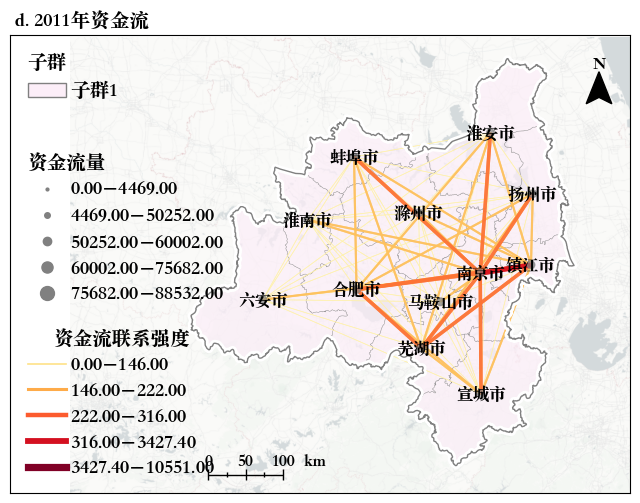

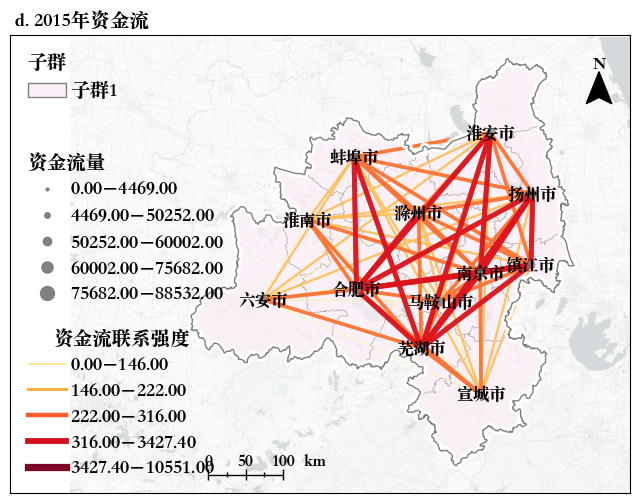

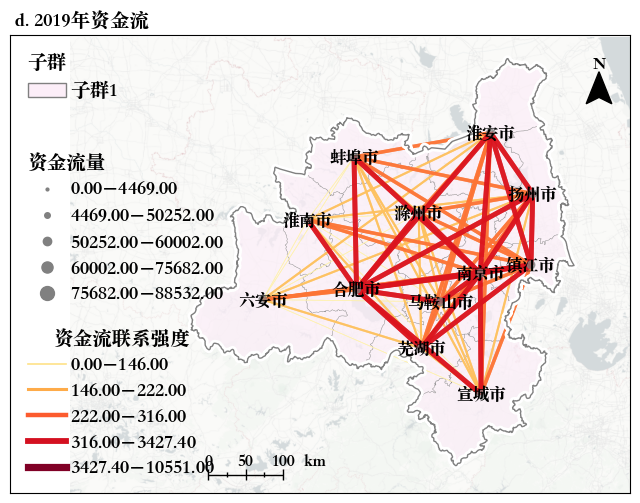

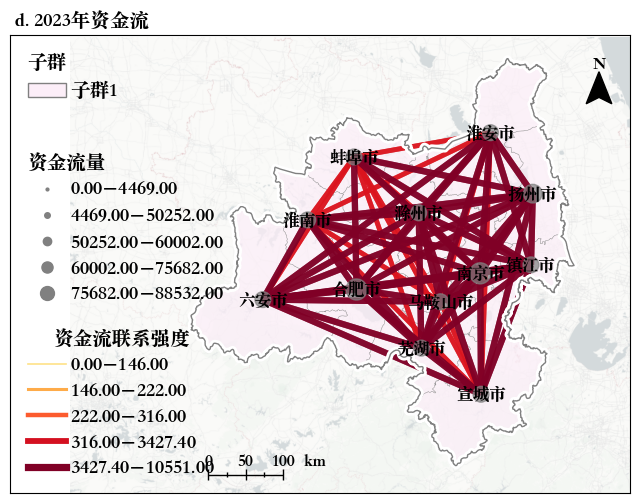

In [71]:
topo = pd.DataFrame()
centra = pd.DataFrame()
dominant = pd.DataFrame()
pgrank = pd.DataFrame()

for name in ['交通流','信息流','科技流','资金流','综合流'][3:4]:
    path = '/Users/xuzzhan/Documents/xianyu/要素流和综合流/'
    df_melt_all = pd.DataFrame()
    for year in [11,15,19,23]:
        try:
            df = pd.read_csv(path + f'{year}年/20{year}年{name}.csv')
        except:
            df = pd.read_csv(path + f'{year}年/20{year}年{name}.csv', encoding='gb18030')
        df.columns = ['城市'] + list(df.columns[1:])
        df_melt = df.melt(id_vars='城市')
        df_melt_all = pd.concat([df_melt_all, df_melt[df_melt['城市']!=df_melt['variable']].assign(年份=year)])
    # df_melt_all['value'] = np.log(df_melt_all['value'])
    for year in [11,15,19,23]:
        ppp = Processing(year, name, df_melt_all, 'quantiles')
        ppp.get_results()
        topo = pd.concat([topo, pd.DataFrame(ppp.topology, index=[f'20{ppp.year}{ppp.name}'])])
        centra = pd.concat([centra, ppp.df_centrality.reset_index().assign(year=f'20{ppp.year}{ppp.name}')])
        dominant = pd.concat([dominant, ppp.dominant_flow.reset_index().assign(year=f'20{ppp.year}{ppp.name}')])
        pgrank = pd.concat([pgrank, pd.DataFrame(ppp.analyzer.pr, index=[f'20{year}年{ppp.name}'])])
        ax=ppp.plot()
        plt.savefig(f'/Users/xuzzhan/Documents/xianyu/要素流和综合流/figures/20{ppp.year}年{ppp.name}.jpg', dpi=300, bbox_inches='tight')
        # break
    # break

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(8,9),dpi=300)
ax = ax.flatten()
for ax_i, year in enumerate([11,15,19,23]):
    for name in ['综合流']:
        ppp = Processing(year, name)
        ppp.get_results()
        ppp.adm.plot(ax=ax[ax_i], facecolor='None', edgecolor='grey', alpha=0.7, lw=0.3)
        all_temp = pd.DataFrame()
        temp = ppp.line_gdf
        for row in ppp.dominant_flow.itertuples():
            all_temp = pd.concat([all_temp, temp[(temp['城市']==row.Index)&(temp['variable']==row.dominant_node)].assign(v=row.dominant_value)])
        all_temp['nb_k'] = mc.EqualInterval(all_temp['v']).yb
        all_temp.plot(color='#e88479', linewidth=all_temp['nb_k']+1.2, zorder=1, legend=True, ax=ax[ax_i])
        ppp.point_gdf.plot(color='#57bef8', edgecolor='black', markersize=ppp.point_gdf['nb_k2']*40+20, ax=ax[ax_i], zorder=2)
        ax[ax_i].set_xticks([]); ax[ax_i].set_yticks([])

        # ax.text(x=0.03, y=0.95, s=f'a.{ppp.name}', transform=ax.transAxes, fontsize=14, ha='left', va='center')
        abcd = {'交通流': 'a', '信息流': 'b', '科技流': 'c', '资金流': 'd', '综合流': 'e'}
        ax[ax_i].set_title(f' {abcd[ppp.name]}. 20{year}年{ppp.name}', fontsize=14, loc='left')

        sn(ax[ax_i]).add_north(type=1, width=0.07, height=0.07, fontsize=12, location='upper left')
        sn(ax[ax_i]).add_scalebar(xpad=0.05, length=1e5, segments=2, fontsize=12)

plt.tight_layout()
LegendElement = [
    mlines.Line2D(
        [0], [0], 
        marker='o',          # 圆点标记
        linestyle='',        # 去掉线条
        markersize=4*i+2,       # 圆点大小（可调整）
        color='#57bef8',
        markeredgecolor='black',
        label=f"{['附属型','次主导型','主导型'][i]}"
    ) 
    for i in range(3)
]
legend1 = fig.legend(
    handles=LegendElement,
    loc="upper right",
    title="城市类别",
    title_fontsize=14,
    fontsize=14,
    frameon=False,
    # handletextpad=0.2,
    ncol=1,
    bbox_to_anchor=(1.19, 0.4),
)
legend1._legend_box.align = "left"
fig.add_artist(legend1)

LegendElement = [mlines.Line2D([0], [0], lw=i+1.2, color='#e88479', label=f"{i+1}")for i in range(5)]
legend2 = fig.legend(
    handles=LegendElement,
    loc="upper right",
    title='优势流等级',
    title_fontsize=14,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(1.15, 0.24),
)
legend2._legend_box.align = "left"
fig.add_artist(legend2)

In [ ]:
pos = nx.spring_layout(ppp.G, seed=1)
nx.draw_networkx_edges(ppp.G, pos, width=0.5, alpha=0.5, edge_color='#e88479')

In [ ]:
pgrank

In [ ]:
topo

In [ ]:
centra

In [ ]:
ppp.dominant_flow

In [ ]:
centra.to_csv('centra.csv', encoding='utf-8-sig')
# dominant.to_csv('dominant.csv', encoding='utf-8-sig')